Environment Installs.

In [1]:
# CELL 0 — Environment Setup
# Run this once per session on instance boot to install missing dependencies.


# Install Weights & Biases for experiment tracking, boto3 for S3 access
!pip install -q wandb boto3 nbstripout

# Lock the Git repository to strip all cell outputs before committing
# This guarantees your WandB API key is never pushed to GitHub
!nbstripout --install

print("Environment secured and dependencies loaded.")

Environment secured and dependencies loaded.


Cell 1 - Dataloader.

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Data Pipeline  (RUN ONCE — data persists on EBS after this)
# Downloads all processed datasets from S3, extracts them locally,
# and builds master train / val / test DataLoaders for EfficientNet-B2.
#
# After this cell completes:
#   - All zip files are deleted automatically as they are extracted
#   - Extracted images live at: /home/ec2-user/SageMaker/training_data/extracted/
#   - Re-running Cells 2-5 does NOT require re-running this cell
#   - Only re-run this cell if you wipe the EBS or change the dataset
#
# Split strategy:
#   Each dataset was already split into train/val/test during preprocessing.
#   This cell reads those pre-existing splits from the folder structure.
#   Nothing is re-split here. The folder name (train/val/test) is the label.
#
# Datasets (~142K total):
#   OpenFake          — 40K  (20K real / 20K fake)
#   DF40 CDF          — 22K  (11K real / 11K fake)
#   DF40 EFS + FFHQ   — 40K  (20K real FFHQ / 20K fake EFS)
#   DF40 Run5 FS      — ~40K (20K real FF++ / 20K fake DF40 FS)
#
# NOTE: OG FF++ (FFPlus) removed from Run 5 — replaced by DF40_Run5_FS
# which uses the same FF++ identity pool. Including both would cause
# identity overlap between training datasets.
#
# Run 5 augmentation additions:
#   HairlineErasing  — randomly erases top 20-25% of image at p=0.4
#                      forces model to find signals beyond hairline boundary
#   FrequencyNoise   — adds low-amplitude FFT noise at p=0.3
#                      teaches model to look for frequency-domain artifacts
# ══════════════════════════════════════════════════════════════════════════════

import os
import json
import random
import shutil
import time
import zipfile
from pathlib import Path

import boto3
import numpy as np
import torch
from PIL import Image
from torch.utils.data import ConcatDataset, DataLoader, Dataset
from torchvision import transforms

# ══════════════════════════════════════════════════════════════════════════════
# REPRODUCIBILITY — lock all seeds before anything else
# ══════════════════════════════════════════════════════════════════════════════

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

generator = torch.Generator()
generator.manual_seed(SEED)

print("Global seeds locked.")

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

S3_BUCKET  = "deepfake-d-100k-dataset-tw26"
LOCAL_BASE = "/home/ec2-user/SageMaker/training_data"
ZIP_DIR    = os.path.join(LOCAL_BASE, "zips")
DATA_DIR   = os.path.join(LOCAL_BASE, "extracted")

BATCH_SIZE  = 64
NUM_WORKERS = 4
SPLITS      = ["train", "val", "test"]
IMG_EXTS    = {".jpg", ".jpeg", ".png", ".webp"}

# ── Dataset registry ──────────────────────────────────────────────────────────
# label_mode:
#   "by_folder"  — assign label by detecting 'real' or 'fake' in the file path
#   "force_real" — every image in this zip is class 1 (real)
#   "force_fake" — every image in this zip is class 0 (fake)

DATASET_CONFIGS = {
    "OpenFake": {
        "zips"      : ["datasets/OpenFake/processed/openfake_processed_faces.zip"],
        "label_mode": "by_folder",
    },
    "DF40_CDF_Real": {
        "zips"      : ["datasets/df40_cdf/df40_cdf_faces_real.zip"],
        "label_mode": "force_real",
    },
    "DF40_CDF_Fake": {
        "zips"      : ["datasets/df40_cdf/df40_cdf_faces_fake.zip"],
        "label_mode": "force_fake",
    },
    "DF40_EFS_Fake": {
        "zips"      : ["datasets/df40_efs_ffpp_faces/df40_efs_ffpp_faces_20k.zip"],
        "label_mode": "force_fake",
    },
    "FFHQ_Real": {
        "zips"      : ["datasets/FFHQ_DF40_EFS_Real/ffhq_real_faces_20k.zip"],
        "label_mode": "force_real",
    },
    "DF40_Run5_FS": {
        "zips"      : ["datasets/df40_run5/final/df40_run5_final_faces.zip"],
        "label_mode": "by_folder",
    },
}

# ══════════════════════════════════════════════════════════════════════════════
# S3 DOWNLOAD
# ══════════════════════════════════════════════════════════════════════════════

os.makedirs(ZIP_DIR,  exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

_s3 = boto3.client("s3")


def download_zip(s3_key, local_dir):
    filename   = os.path.basename(s3_key)
    local_path = os.path.join(local_dir, filename)

    if os.path.exists(local_path) and os.path.getsize(local_path) > 1024:
        print(f"    Cached: {filename}")
        return local_path

    size_mb = _s3.head_object(Bucket=S3_BUCKET, Key=s3_key)["ContentLength"] / (1024**2)
    print(f"    Downloading {filename}  ({size_mb:.0f} MB) ...")
    _s3.download_file(S3_BUCKET, s3_key, local_path)
    print(f"    Done: {filename}")
    return local_path


def extract_zip(zip_path, extract_to):
    print(f"    Extracting {os.path.basename(zip_path)} ...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_to)
    os.remove(zip_path)
    print(f"    Extracted -> {extract_to}  (zip deleted)")

# ══════════════════════════════════════════════════════════════════════════════
# FLEXIBLE IMAGE DATASET
# ══════════════════════════════════════════════════════════════════════════════

CACHE_DIR = os.path.join(LOCAL_BASE, "cache")
os.makedirs(CACHE_DIR, exist_ok=True)


class FlexibleImageDataset(Dataset):
    """
    Scans a directory recursively for all image files and assigns labels:
      - by_folder : checks if "real" or "fake" is an exact folder name component
                   in the path (uses Path.parts, NOT substring matching)
      - force_real: every image is class 1
      - force_fake: every image is class 0

    split: "train" | "val" | "test" — only includes files where the split name
           is an exact folder name component (Path.parts), not a substring match.

    File lists are cached to JSON on first scan to avoid rescanning 142K files
    on every cell re-run. Delete the cache/ directory to force a fresh scan.
    """

    def __init__(self, root_dir, label_mode, split, transform=None, ds_name=""):
        self.transform = transform
        self.samples   = []

        cache_key  = f"{ds_name}_{label_mode}_{split}.json"
        cache_path = os.path.join(CACHE_DIR, cache_key)

        if os.path.exists(cache_path):
            print(f"      Loading cached file list: {cache_key}")
            with open(cache_path) as f:
                self.samples = [tuple(x) for x in json.load(f)]
        else:
            root_path = Path(root_dir)
            skipped   = 0

            for img_path in sorted(root_path.rglob("*")):
                if img_path.suffix.lower() not in IMG_EXTS:
                    continue

                parts = [p.lower() for p in img_path.parts]
                if split not in parts:
                    continue

                label = self._assign_label(img_path, label_mode, parts)
                if label is not None:
                    self.samples.append((str(img_path), label))
                else:
                    skipped += 1

            if skipped > 0:
                print(
                    f"      WARNING [{ds_name} / {split}]: {skipped} image(s) skipped — "
                    f"path contained neither 'real' nor 'fake' as a folder name component. "
                    f"Check extracted folder structure if this number is unexpectedly high."
                )

            if not self.samples:
                raise ValueError(
                    f"No images found in {root_dir} for split='{split}' "
                    f"with label_mode='{label_mode}'.\n"
                    f"Check that the zip extracted correctly and contains a '{split}/' subfolder."
                )

            with open(cache_path, "w") as f:
                json.dump(self.samples, f)
            print(f"      Cached file list: {cache_key}")

    def _assign_label(self, img_path, label_mode, parts):
        if label_mode == "force_real":
            return 1
        if label_mode == "force_fake":
            return 0
        if label_mode == "by_folder":
            if "real" in parts:
                return 1
            if "fake" in parts:
                return 0
            return None
        if label_mode == "by_folder_prefix":
            for part in parts:
                if part == "real":
                    return 1
                if part.startswith("fake"):
                    return 0
            return None
        raise ValueError(f"Unknown label_mode: {label_mode}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            return self.__getitem__((idx + 1) % len(self.samples))
        if self.transform:
            img = self.transform(img)
        return img, label

# ══════════════════════════════════════════════════════════════════════════════
# RUN 5 CUSTOM AUGMENTATIONS
# Applied after ToTensor, before Normalize.
# Both are uniform across all samples — no class-conditional logic.
# ══════════════════════════════════════════════════════════════════════════════

class HairlineErasing:
    """
    Randomly erases the top 20-25% of the image (hairline zone) at p=0.4.
    Applied after ToTensor so input is a CxHxW tensor.
    Forces the model to find discriminative signals beyond the hairline boundary
    rather than anchoring on the easiest spatial cue in FS fakes.
    """
    def __init__(self, p=0.4, erase_ratio_min=0.20, erase_ratio_max=0.25):
        self.p               = p
        self.erase_ratio_min = erase_ratio_min
        self.erase_ratio_max = erase_ratio_max

    def __call__(self, tensor):
        if random.random() > self.p:
            return tensor
        _, H, W     = tensor.shape
        erase_ratio = random.uniform(self.erase_ratio_min, self.erase_ratio_max)
        erase_h     = int(H * erase_ratio)
        tensor[:, :erase_h, :] = 0.0
        return tensor


class FrequencyNoise:
    """
    Adds low-amplitude noise in the frequency domain at p=0.3.
    Perturbs high-frequency components via FFT, forcing the model to learn
    manipulation signals that are robust to frequency-domain variation.
    Prevents the model from latching onto frequency artifacts introduced
    by the preprocessing pipeline rather than the manipulation itself.
    Applied after ToTensor so input is a CxHxW tensor.
    """
    def __init__(self, p=0.3, noise_std=0.02):
        self.p         = p
        self.noise_std = noise_std

    def __call__(self, tensor):
        if random.random() > self.p:
            return tensor
        tensor_np = tensor.numpy()
        noisy     = np.zeros_like(tensor_np)
        for c in range(tensor_np.shape[0]):
            fft_channel = np.fft.fft2(tensor_np[c])
            noise       = (
                np.random.normal(0, self.noise_std, fft_channel.shape) +
                1j * np.random.normal(0, self.noise_std, fft_channel.shape)
            )
            fft_noisy = fft_channel + noise
            noisy[c]  = np.real(np.fft.ifft2(fft_noisy)).astype(np.float32)
        return torch.from_numpy(np.clip(noisy, -3.0, 3.0))

# ══════════════════════════════════════════════════════════════════════════════
# TRANSFORMS
# ══════════════════════════════════════════════════════════════════════════════

# Training augmentation — Run 5: added HairlineErasing and FrequencyNoise
# on top of Run 3 augmentations to address hairline-anchoring bias identified
# via Grad-CAM analysis and improve cross-domain generalisation.
train_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.3
    ),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    HairlineErasing(p=0.4, erase_ratio_min=0.20, erase_ratio_max=0.25),
    FrequencyNoise(p=0.3, noise_std=0.02),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Val and test — no augmentation, deterministic
val_test_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ══════════════════════════════════════════════════════════════════════════════
# DOWNLOAD + EXTRACT ALL DATASETS
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  Downloading and extracting datasets from S3")
print("=" * 60 + "\n")

dataset_roots = {}

for ds_name, config in DATASET_CONFIGS.items():
    print(f"  [{ds_name}]")
    extract_root = os.path.join(DATA_DIR, ds_name)
    os.makedirs(extract_root, exist_ok=True)

    for s3_key in config["zips"]:
        local_zip = download_zip(s3_key, ZIP_DIR)
        extract_zip(local_zip, extract_root)

    dataset_roots[ds_name] = extract_root
    print()

print("All datasets downloaded and extracted.\n")

leftover_zips = list(Path(ZIP_DIR).glob("*.zip"))
if leftover_zips:
    print(f"WARNING: {len(leftover_zips)} zip(s) not cleaned up — deleting now:")
    for z in leftover_zips:
        print(f"  Removing: {z.name}")
        z.unlink()
else:
    print("Zip cleanup confirmed — no zip files remaining on EBS.")

import shutil as _shutil
total, used, free = _shutil.disk_usage("/home/ec2-user/SageMaker")
print(f"\nEBS disk usage:")
print(f"  Used  : {used  / (1024**3):.1f} GB")
print(f"  Free  : {free  / (1024**3):.1f} GB")
print(f"  Total : {total / (1024**3):.1f} GB")
print()

# ══════════════════════════════════════════════════════════════════════════════
# BUILD SPLIT DATASETS AND VERIFY
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  Building datasets and verifying counts")
print("=" * 60 + "\n")

split_datasets = {s: [] for s in SPLITS}

for ds_name, config in DATASET_CONFIGS.items():
    root       = dataset_roots[ds_name]
    label_mode = config["label_mode"]

    print(f"  {ds_name}  (label_mode={label_mode})")
    for split in SPLITS:
        transform = train_transform if split == "train" else val_test_transform
        try:
            ds = FlexibleImageDataset(root, label_mode, split, transform=transform, ds_name=ds_name)
            split_datasets[split].append(ds)

            real_count = sum(1 for _, lbl in ds.samples if lbl == 1)
            fake_count = sum(1 for _, lbl in ds.samples if lbl == 0)
            print(f"    {split:<6}: {len(ds):>6,} images  "
                  f"(real={real_count:,}  fake={fake_count:,})")
        except ValueError as e:
            print(f"    {split:<6}: WARNING — {e}")
    print()

# ══════════════════════════════════════════════════════════════════════════════
# MERGE INTO MASTER DATASETS
# ══════════════════════════════════════════════════════════════════════════════

master_train = ConcatDataset(split_datasets["train"])
master_val   = ConcatDataset(split_datasets["val"])
master_test  = ConcatDataset(split_datasets["test"])

print("=" * 60)
print("  Master dataset summary")
print("=" * 60)
print(f"  Train : {len(master_train):>7,} images")
print(f"  Val   : {len(master_val):>7,} images")
print(f"  Test  : {len(master_test):>7,} images")
print(f"  Total : {len(master_train) + len(master_val) + len(master_test):>7,} images")

_total_images    = len(master_train) + len(master_val) + len(master_test)
MIN_TOTAL_IMAGES = 140_000
if _total_images < MIN_TOTAL_IMAGES:
    raise RuntimeError(
        f"Total dataset size ({_total_images:,}) is below the expected minimum "
        f"({MIN_TOTAL_IMAGES:,}). One or more datasets may have been silently "
        f"dropped due to label_mode mismatch or extraction failure. "
        f"Check the per-dataset counts above for zero-fake or zero-real splits."
    )

_total, _used, _free = _shutil.disk_usage("/home/ec2-user/SageMaker")
print(f"\n  EBS headroom after dataset load:")
print(f"    Used : {_used  / (1024**3):.1f} GB")
print(f"    Free : {_free  / (1024**3):.1f} GB")

# ══════════════════════════════════════════════════════════════════════════════
# DATALOADERS
# ══════════════════════════════════════════════════════════════════════════════

PIN_MEMORY = torch.cuda.is_available()

def worker_init_fn(worker_id):
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)

train_loader = DataLoader(
    master_train,
    batch_size         = BATCH_SIZE,
    shuffle            = True,
    num_workers        = NUM_WORKERS,
    pin_memory         = PIN_MEMORY,
    drop_last          = True,
    generator          = generator,
    worker_init_fn     = worker_init_fn,
    persistent_workers = True,
)

val_loader = DataLoader(
    master_val,
    batch_size         = BATCH_SIZE,
    shuffle            = False,
    num_workers        = NUM_WORKERS,
    pin_memory         = PIN_MEMORY,
    worker_init_fn     = worker_init_fn,
    persistent_workers = True,
)

test_loader = DataLoader(
    master_test,
    batch_size         = BATCH_SIZE,
    shuffle            = False,
    num_workers        = NUM_WORKERS,
    pin_memory         = PIN_MEMORY,
    worker_init_fn     = worker_init_fn,
    persistent_workers = True,
)

print(f"\n  Train batches : {len(train_loader):,}  (batch_size={BATCH_SIZE}, pin_memory={PIN_MEMORY})")
print(f"  Val batches   : {len(val_loader):,}")
print(f"  Test batches  : {len(test_loader):,}")

print("\n  Running dataloader sanity check...")
sample_imgs, sample_labels = next(iter(train_loader))
assert sample_imgs.shape == (BATCH_SIZE, 3, 260, 260), \
    f"Unexpected image shape: {sample_imgs.shape}"
assert set(sample_labels.unique().tolist()).issubset({0, 1}), \
    f"Unexpected label values: {sample_labels.unique()}"
print(f"  Batch shape  : {tuple(sample_imgs.shape)}")
print(f"  Label range  : {sample_labels.min().item()} – {sample_labels.max().item()}")
print(f"  Real in batch: {(sample_labels == 1).sum().item()}")
print(f"  Fake in batch: {(sample_labels == 0).sum().item()}")
print("\n  The Funnel is Locked In.")

Global seeds locked.


  [OpenFake]
    Done: openfake_processed_faces.zip
    Extracting openfake_processed_faces.zip ...
    Extracted -> /home/ec2-user/SageMaker/training_data/extracted/OpenFake  (zip deleted)

  [DF40_CDF_Real]
    Done: df40_cdf_faces_real.zip
    Extracting df40_cdf_faces_real.zip ...
    Extracted -> /home/ec2-user/SageMaker/training_data/extracted/DF40_CDF_Real  (zip deleted)

  [DF40_CDF_Fake]
    Done: df40_cdf_faces_fake.zip
    Extracting df40_cdf_faces_fake.zip ...
    Extracted -> /home/ec2-user/SageMaker/training_data/extracted/DF40_CDF_Fake  (zip deleted)

  [DF40_EFS_Fake]
    Done: df40_efs_ffpp_faces_20k.zip
    Extracting df40_efs_ffpp_faces_20k.zip ...
    Extracted -> /home/ec2-user/SageMaker/training_data/extracted/DF40_EFS_Fake  (zip deleted)

  [FFHQ_Real]
    Done: ffhq_real_faces_20k.zip
    Extracting ffhq_real_faces_20k.zip ...
    Extracted -> /home/ec2-user/SageMaker/training_data/extracted/FFHQ_Real  (zip deleted)

  [DF40_Run5_FS]
    D

Cell 1-B - Audit.

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1B — Master Dataset Diagnostic Audit
# Run immediately after Cell 1 to verify the full dataset is loaded correctly
# before committing to a multi-hour training run.
#
# Checks:
#   - Total image count per dataset, per split, per class
#   - Overall real / fake balance
#   - Flags any dataset with zero fakes or zero reals (silent drop indicator)
#   - Confirms total is within expected range
#
# Run 5 datasets (OG FF++ removed — replaced by DF40_Run5_FS):
#   OpenFake, DF40_CDF_Real, DF40_CDF_Fake, DF40_EFS_Fake, FFHQ_Real, DF40_Run5_FS
# ══════════════════════════════════════════════════════════════════════════════

import json as _json

print("\n" + "=" * 70)
print("  CELL 1B — Master Dataset Diagnostic Audit")
print("=" * 70)

# ── Per-dataset breakdown ─────────────────────────────────────────────────────
print(f"\n  {'Dataset':<22} {'Split':<8} {'Total':>8} {'Real':>8} {'Fake':>8}  {'Status'}")
print(f"  {'-'*22}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*10}")

EXPECTED_DATASETS = list(DATASET_CONFIGS.keys())
issues_found      = []

for ds_name in EXPECTED_DATASETS:
    config     = DATASET_CONFIGS[ds_name]
    label_mode = config["label_mode"]

    for split in SPLITS:
        cache_key  = f"{ds_name}_{label_mode}_{split}.json"
        cache_path = os.path.join(CACHE_DIR, cache_key)

        if not os.path.exists(cache_path):
            print(f"  {ds_name:<22} {split:<8} {'CACHE MISSING — re-run Cell 1':>30}")
            issues_found.append(f"{ds_name}/{split}: cache file missing")
            continue

        with open(cache_path) as f:
            samples = [tuple(x) for x in _json.load(f)]

        total = len(samples)
        real  = sum(1 for _, lbl in samples if lbl == 1)
        fake  = sum(1 for _, lbl in samples if lbl == 0)

        if total == 0:
            status = "EMPTY"
            issues_found.append(f"{ds_name}/{split}: zero images loaded")
        elif fake == 0 and label_mode not in ("force_real",):
            status = "NO FAKES"
            issues_found.append(f"{ds_name}/{split}: zero fake images — check label_mode")
        elif real == 0 and label_mode not in ("force_fake",):
            status = "NO REALS"
            issues_found.append(f"{ds_name}/{split}: zero real images — check label_mode")
        else:
            status = "OK"

        print(f"  {ds_name:<22} {split:<8} {total:>8,} {real:>8,} {fake:>8,}  {status}")

# ── Master totals ─────────────────────────────────────────────────────────────
total_train = len(master_train)
total_val   = len(master_val)
total_test  = len(master_test)
grand_total = total_train + total_val + total_test

all_real = 0
all_fake = 0

for ds_name in EXPECTED_DATASETS:
    label_mode = DATASET_CONFIGS[ds_name]["label_mode"]
    for split in SPLITS:
        cache_key  = f"{ds_name}_{label_mode}_{split}.json"
        cache_path = os.path.join(CACHE_DIR, cache_key)
        if os.path.exists(cache_path):
            with open(cache_path) as f:
                samples = [tuple(x) for x in _json.load(f)]
            all_real += sum(1 for _, lbl in samples if lbl == 1)
            all_fake += sum(1 for _, lbl in samples if lbl == 0)

print(f"\n  {'─' * 66}")
print(f"  {'MASTER TOTALS':<22} {'':8} {grand_total:>8,} {all_real:>8,} {all_fake:>8,}")
print(f"\n  Train : {total_train:>8,} images")
print(f"  Val   : {total_val:>8,} images")
print(f"  Test  : {total_test:>8,} images")
print(f"  Total : {grand_total:>8,} images")
print(f"\n  Real  : {all_real:>8,}  ({all_real / grand_total * 100:.1f}%)")
print(f"  Fake  : {all_fake:>8,}  ({all_fake / grand_total * 100:.1f}%)")

# ── Balance check ─────────────────────────────────────────────────────────────
balance_ratio = (
    min(all_real, all_fake) / max(all_real, all_fake)
    if max(all_real, all_fake) > 0 else 0
)
print(f"  Balance ratio : {balance_ratio:.3f}  (1.000 = perfect, <0.85 = concerning)")
if balance_ratio < 0.85:
    issues_found.append(
        f"Class imbalance: real={all_real:,} fake={all_fake:,} ratio={balance_ratio:.3f}"
    )

# ── Dataset presence check — confirm Run5 FS is loaded, OG FF++ is absent ────
print(f"\n  {'─' * 66}")
print("  DATASET PRESENCE CHECK")
print(f"  {'─' * 66}")

required_present = ["DF40_Run5_FS"]
must_be_absent   = ["FFPlus"]

for ds in required_present:
    if ds in EXPECTED_DATASETS:
        print(f"  [OK]     {ds} — present")
    else:
        print(f"  [FAIL]   {ds} — MISSING from DATASET_CONFIGS")
        issues_found.append(f"{ds} is required but missing from DATASET_CONFIGS")

for ds in must_be_absent:
    if ds not in EXPECTED_DATASETS:
        print(f"  [OK]     {ds} — correctly excluded (identity overlap prevention)")
    else:
        print(f"  [FAIL]   {ds} — present but should be excluded (FF++ identity overlap)")
        issues_found.append(f"{ds} must be removed — FF++ identities overlap with DF40_Run5_FS")

# ── Minimum count guard ───────────────────────────────────────────────────────
MIN_TOTAL_IMAGES = 140_000
print(f"\n  Minimum expected : {MIN_TOTAL_IMAGES:,}")
print(f"  Actual total     : {grand_total:,}")
if grand_total < MIN_TOTAL_IMAGES:
    issues_found.append(
        f"Total images ({grand_total:,}) below minimum ({MIN_TOTAL_IMAGES:,})"
    )

# ── Final verdict ─────────────────────────────────────────────────────────────
print(f"\n{'=' * 70}")
if issues_found:
    print(f"  AUDIT FAILED — {len(issues_found)} issue(s) detected:")
    for issue in issues_found:
        print(f"    {issue}")
    print(f"\n  DO NOT proceed to Cell 2. Fix the issues above and re-run Cell 1.")
    raise RuntimeError(
        f"Dataset audit failed with {len(issues_found)} issue(s). "
        f"See printed report above."
    )
else:
    print(f"  AUDIT PASSED — dataset looks correct. Safe to proceed to Cell 2.")
print("=" * 70 + "\n")


  CELL 1B — Master Dataset Diagnostic Audit

  Dataset                Split       Total     Real     Fake  Status
  ----------------------  --------  --------  --------  --------  ----------
  OpenFake               train      28,000   14,000   14,000  OK
  OpenFake               val         6,000    3,000    3,000  OK
  OpenFake               test        6,000    3,000    3,000  OK
  DF40_CDF_Real          train       7,755    7,755        0  OK
  DF40_CDF_Real          val         1,693    1,693        0  OK
  DF40_CDF_Real          test        1,661    1,661        0  OK
  DF40_CDF_Fake          train       7,755        0    7,755  OK
  DF40_CDF_Fake          val         1,693        0    1,693  OK
  DF40_CDF_Fake          test        1,661        0    1,661  OK
  DF40_EFS_Fake          train      14,000        0   14,000  OK
  DF40_EFS_Fake          val         3,000        0    3,000  OK
  DF40_EFS_Fake          test        3,000        0    3,000  OK
  FFHQ_Real              tra

Cell 2 - EN B2 Setup.

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — EfficientNet-B2 Model Setup
# Loads pretrained EfficientNet-B2, attaches a 2-class deepfake detection head,
# mounts to GPU, defines optimizer and loss function.
#
# Architecture strategy (two-phase training):
#   Phase 1 — Frozen base, train head only (fast convergence, avoid destroying
#              pretrained features before the head is calibrated)
#   Phase 2 — Full unfreeze, fine-tune entire network at low LR
#
# Label convention (must match Cell 1):
#   0 = Fake
#   1 = Real
# ══════════════════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
from torchvision import models

# ══════════════════════════════════════════════════════════════════════════════
# GPU CHECK
# ══════════════════════════════════════════════════════════════════════════════

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device         : {device.type.upper()}")
if device.type == "cuda":
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"VRAM total     : {torch.cuda.get_device_properties(0).total_memory / (1024**3):.1f} GB")
    print(f"VRAM free      : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / (1024**3):.1f} GB")
else:
    print("WARNING: No GPU detected. Training will be extremely slow.")

# ══════════════════════════════════════════════════════════════════════════════
# MODEL — EFFICIENTNET-B2 WITH CUSTOM CLASSIFICATION HEAD
# ══════════════════════════════════════════════════════════════════════════════

print("\nLoading pretrained EfficientNet-B2 (ImageNet weights)...")
weights = models.EfficientNet_B2_Weights.DEFAULT
model   = models.efficientnet_b2(weights=weights)

# Phase 1 default: freeze all base layers
# Only the classification head will be trained initially
print("Freezing base layers for Phase 1 warmup...")
for param in model.parameters():
    param.requires_grad = False

# Replace the 1000-class ImageNet head with a 2-class deepfake detection head
# EfficientNet-B2 classifier input features: 1408
in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),          # inplace=True removed — avoids in-place corruption of saved activations
    nn.Linear(in_features, 2)
)

# Head parameters are trainable by default (newly created layers)
model = model.to(device)

# ══════════════════════════════════════════════════════════════════════════════
# BATCHNORM FREEZE HELPER
# During Phase 1, BatchNorm running statistics must not update even when the
# rest of the model is in train() mode. This helper is called inside the
# training loop immediately after model.train() to enforce eval mode on all
# BatchNorm2d layers throughout Phase 1.
# ══════════════════════════════════════════════════════════════════════════════

def freeze_batchnorm(model):
    """
    Set all BatchNorm2d layers to eval() mode.
    Call this immediately after model.train() during Phase 1 to prevent
    running mean/variance drift from corrupting pretrained feature statistics.
    """
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()

# ══════════════════════════════════════════════════════════════════════════════
# PARAMETER AUDIT
# ══════════════════════════════════════════════════════════════════════════════

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"\nParameter audit:")
print(f"  Total      : {total_params:,}")
print(f"  Trainable  : {trainable_params:,}  (head only — Phase 1)")
print(f"  Frozen     : {frozen_params:,}")

# ══════════════════════════════════════════════════════════════════════════════
# PHASE 1 OPTIMIZER AND LOSS
# Trains only the classification head at a standard LR
# ══════════════════════════════════════════════════════════════════════════════

PHASE1_LR     = 1e-3
WEIGHT_DECAY  = 1e-4

optimizer_phase1 = torch.optim.AdamW(
    model.classifier.parameters(),
    lr           = PHASE1_LR,
    weight_decay = WEIGHT_DECAY,
)

criterion = nn.CrossEntropyLoss()

print(f"\nPhase 1 optimizer  : AdamW  lr={PHASE1_LR}  weight_decay={WEIGHT_DECAY}")
print(f"Loss function      : CrossEntropyLoss")
print(f"BatchNorm handling : freeze_batchnorm() must be called after model.train() in Phase 1 loop")

# ══════════════════════════════════════════════════════════════════════════════
# FORWARD PASS SANITY CHECK
# Confirms model accepts the expected input shape and outputs [batch, 2]
# ══════════════════════════════════════════════════════════════════════════════

print("\nRunning forward pass sanity check...")
model.eval()
with torch.no_grad():
    dummy = torch.randn(2, 3, 260, 260).to(device)
    out   = model(dummy)

assert out.shape == (2, 2), \
    f"Unexpected output shape: {out.shape}. Expected (2, 2)."

print(f"  Input shape  : {tuple(dummy.shape)}")
print(f"  Output shape : {tuple(out.shape)}  — 2 classes confirmed")
print(f"  Sample logits: {out[0].cpu().numpy().round(4)}")

# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  CELL 2 COMPLETE — Model Ready")
print("=" * 60)
print(f"  Architecture    : EfficientNet-B2 (pretrained ImageNet)")
print(f"  Head            : Dropout(0.3) -> Linear({in_features}, 2)")
print(f"  Input size      : 260 x 260")
print(f"  Classes         : 0=Fake  1=Real")
print(f"  Phase 1 optimizer : AdamW  lr={PHASE1_LR}  weight_decay={WEIGHT_DECAY}")
print(f"  BatchNorm Phase 1 : freeze_batchnorm() enforced inside training loop")
print(f"  Device          : {device.type.upper()}")
print("=" * 60)
print("\nProceed to Cell 3 (WandB setup) then Cell 4 (training loop).")

Device         : CUDA
GPU            : NVIDIA L4
VRAM total     : 22.0 GB
VRAM free      : 22.0 GB

Loading pretrained EfficientNet-B2 (ImageNet weights)...
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /home/ec2-user/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 298MB/s]


Freezing base layers for Phase 1 warmup...

Parameter audit:
  Total      : 7,703,812
  Trainable  : 2,818  (head only — Phase 1)
  Frozen     : 7,700,994

Phase 1 optimizer  : AdamW  lr=0.001  weight_decay=0.0001
Loss function      : CrossEntropyLoss
BatchNorm handling : freeze_batchnorm() must be called after model.train() in Phase 1 loop

Running forward pass sanity check...
  Input shape  : (2, 3, 260, 260)
  Output shape : (2, 2)  — 2 classes confirmed
  Sample logits: [ 0.071  -0.0175]

  CELL 2 COMPLETE — Model Ready
  Architecture    : EfficientNet-B2 (pretrained ImageNet)
  Head            : Dropout(0.3) -> Linear(1408, 2)
  Input size      : 260 x 260
  Classes         : 0=Fake  1=Real
  Phase 1 optimizer : AdamW  lr=0.001  weight_decay=0.0001
  BatchNorm Phase 1 : freeze_batchnorm() enforced inside training loop
  Device          : CUDA

Proceed to Cell 3 (WandB setup) then Cell 4 (training loop).


Cell 3-A - WandB API Token Setup. 

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3a — Secure WandB API Key Setup (Safe for Git)
# ══════════════════════════════════════════════════════════════════════════════
#
# This cell uses `getpass` to securely prompt for your API key. 
# - The key will NOT be saved in the notebook's source code.
# - The pasted text will be hidden from the output block.
# - You can safely commit this cell without modifying it.
# ══════════════════════════════════════════════════════════════════════════════

import os
import getpass

print("Enter your WandB API key (input will be hidden):")
os.environ["WANDB_API_KEY"] = getpass.getpass()

print("WANDB_API_KEY loaded into environment securely.")

Cell 3-B - WandB Setup

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3b — WandB Initialisation (safe to push to git, no secrets here)
# Reads WANDB_API_KEY from environment set in Cell 3a.
#
# Git safety — the real protection beyond clearing outputs:
#   Option 1 (simplest): add to .gitignore
#     echo "*.ipynb" >> .gitignore
#   Option 2 (cleanest): use nbstripout which automatically strips all cell
#     outputs before every git commit so you cannot accidentally push secrets
#     pip install nbstripout
#     nbstripout --install   (run once in the repo root)
# ══════════════════════════════════════════════════════════════════════════════

import os
import wandb

# ══════════════════════════════════════════════════════════════════════════════
# WANDB MODE — switch to "offline" if network is slow or you want fast iteration
# Offline runs sync to WandB later with: wandb sync wandb/latest-run
# ══════════════════════════════════════════════════════════════════════════════

WANDB_MODE = "online"   # "online" | "offline" | "disabled"
os.environ["WANDB_MODE"] = WANDB_MODE

# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT CONFIGURATION
# Update RUN_NAME before each experiment so runs are distinguishable in WandB
# ══════════════════════════════════════════════════════════════════════════════

PROJECT_NAME = "deepfake-detection-honours"
RUN_NAME     = "effnetb2-run4-extended-35ep"   # update per experiment

WANDB_CONFIG = {
    "architecture"     : "EfficientNet-B2",
    "dataset"          : "122K multi-source (OpenFake + FFPlus + DF40-CDF + DF40-EFS + FFHQ)",
    # Pulled from actual Cell 1 counts — never hardcoded
    "total_images"     : len(master_train) + len(master_val) + len(master_test),
    "train_images"     : len(master_train),
    "val_images"       : len(master_val),
    "test_images"      : len(master_test),
    "input_size"       : "260x260",
    "batch_size"       : BATCH_SIZE,
    "phase1_lr"        : PHASE1_LR,
    "phase1_epochs"    : 5,
    "phase2_lr"        : 1e-5,
    "phase2_epochs"    : 15,
    "optimizer"        : "AdamW",
    "weight_decay"     : WEIGHT_DECAY,
    "loss"             : "CrossEntropyLoss",
    "dropout"          : 0.3,
    "augmentation"     : "HFlip + ColorJitter + GaussianBlur",
    "labels"           : "0=Fake  1=Real",
    "seed"             : SEED,
    "wandb_mode"       : WANDB_MODE,
}

# ══════════════════════════════════════════════════════════════════════════════
# AUTHENTICATE AND INITIALISE
# ══════════════════════════════════════════════════════════════════════════════

api_key = os.environ.get("WANDB_API_KEY", "")

if WANDB_MODE == "online":
    if not api_key or api_key == "PASTE_YOUR_KEY_HERE":
        raise RuntimeError(
            "WANDB_API_KEY is not set or still contains the placeholder.\n"
            "Run Cell 3a first with your actual WandB API key."
        )
    wandb.login(key=api_key)

try:
    wandb.finish()
except Exception:
    pass

run = wandb.init(
    project = PROJECT_NAME,
    name    = RUN_NAME,
    config  = WANDB_CONFIG,
    reinit  = True,
)

print(f"WandB run initialised  (mode={WANDB_MODE})")
print(f"  Project      : {PROJECT_NAME}")
print(f"  Run          : {RUN_NAME}")
print(f"  Train images : {len(master_train):,}")
print(f"  Val images   : {len(master_val):,}")
print(f"  Test images  : {len(master_test):,}")
print(f"  Total        : {len(master_train) + len(master_val) + len(master_test):,}")
if run is not None:
    print(f"  URL          : {run.url}")

Cell 4 - Training / Validation.

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Two-Phase Training Loop
#
# Phase 1 — Head warmup (5 epochs)
#   - Base frozen, head only
#   - AdamW lr=1e-3
#   - BatchNorm frozen via freeze_batchnorm() on every iteration
#   - Prevents pretrained feature drift before the head is calibrated
#
# Phase 2 — Full fine-tuning (15 epochs)
#   - All layers unfrozen
#   - AdamW lr=1e-5
#   - ReduceLROnPlateau scheduler
#   - Gradient clipping at max_norm=1.0
#
# Checkpointing: saves best model by val loss across both phases combined
# WandB: logs train loss, val loss, val acc, val F1, val AUC, LR per epoch
# ══════════════════════════════════════════════════════════════════════════════

import os
import time
import numpy as np
import torch
import torch.nn.functional as F
import wandb
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

PHASE1_EPOCHS   = 5
PHASE2_EPOCHS   = 35
PHASE1_LR       = 1e-3   # used in Phase 1 optimizer (Cell 2) and print below
PHASE2_LR       = 1e-5
GRAD_CLIP_NORM  = 1.0
EARLY_STOP_PATIENCE = 7   # > scheduler patience (2) + grace period for LR reduction to take effect
                          # scheduler fires at patience=2, model needs a few more epochs to respond

CHECKPOINT_DIR   = "/home/ec2-user/SageMaker/checkpoints"
CHECKPOINT_BEST  = os.path.join(CHECKPOINT_DIR, "best_effnetb2.pth")
CHECKPOINT_LAST  = os.path.join(CHECKPOINT_DIR, "last_effnetb2.pth")   # Fix 6: recovery checkpoint

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Fix 3: GradScaler for mixed precision — disabled automatically on CPU
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def run_epoch_train(phase):
    """
    Run one training epoch.
    phase: "phase1" | "phase2"
    Fix 1: freeze_batchnorm() called ONCE per epoch after model.train(),
            not inside the batch loop — optimizer.step() does not change
            train/eval mode so re-calling per batch is wasted compute.
    Fix 2: gradient clipping applied only to params with gradients.
    Fix 3: forward pass and loss wrapped in autocast for mixed precision.
    """
    model.train()
    if phase == "phase1":
        freeze_batchnorm(model)   # Fix 1: once per epoch, not per batch

    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).long()

        optimizer.zero_grad(set_to_none=True)

        # Fix 3: autocast for mixed precision (no-op on CPU)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(inputs)

            if outputs.ndim != 2 or outputs.size(1) != 2:
                raise ValueError(
                    f"Unexpected model output shape: {tuple(outputs.shape)}. "
                    f"Expected [batch_size, 2]. Check the classification head."
                )

            loss = criterion(outputs, labels)

        # Fix 3: scaler handles backward and optimizer step
        scaler.scale(loss).backward()

        # Fix 2: unscale before clipping, then clip only trainable params
        scaler.unscale_(optimizer)
        trainable_params = [p for p in model.parameters() if p.requires_grad and p.grad is not None]
        torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=GRAD_CLIP_NORM)

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(train_loader.dataset)


def run_epoch_val():
    """
    Run one validation epoch. No gradient computation.
    autocast applied here too for numeric consistency with training
    and to avoid wasted performance in full precision.
    Returns loss, accuracy, F1, AUC.
    """
    model.eval()
    running_loss = 0.0
    all_labels, all_probs, all_preds = [], [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).long()

            # Fix 1: autocast in validation for numeric consistency with training
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(inputs)

                if outputs.ndim != 2 or outputs.size(1) != 2:
                    raise ValueError(
                        f"Unexpected model output shape: {tuple(outputs.shape)}. "
                        f"Expected [batch_size, 2]."
                    )

                loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            probs = F.softmax(outputs.float(), dim=1)[:, 1]   # cast to float32 for softmax stability
            preds = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())

    val_loss = running_loss / len(val_loader.dataset)
    val_acc  = accuracy_score(all_labels, all_preds)
    val_f1   = f1_score(all_labels, all_preds, zero_division=0)

    if len(set(all_labels)) > 1:
        val_auc = roc_auc_score(all_labels, all_probs)
    else:
        val_auc = None
        # Fix 5: visible warning so imbalanced val batches don't silently degrade metrics
        print("  WARNING: val AUC undefined this epoch — only one class present in val labels.")

    return val_loss, val_acc, val_f1, val_auc


def save_checkpoint(epoch, val_loss, val_acc, val_f1, val_auc, phase, is_best):
    checkpoint = {
        "epoch"               : epoch,
        "phase"               : phase,
        "model_state_dict"    : model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if phase == "phase2" else None,
        # Fix 2 (from Cell 5): only save scaler state when CUDA available
        "scaler_state_dict"   : scaler.state_dict() if torch.cuda.is_available() else None,
        "best_val_loss"       : val_loss,
        "best_val_acc"        : val_acc,
        "best_val_f1"         : val_f1,
        "best_val_auc"        : val_auc if val_auc is not None else 0.0,
    }
    # Fix 6: atomic save — write to temp then rename to avoid corrupt files on crash
    tmp_last = CHECKPOINT_LAST + ".tmp"
    torch.save(checkpoint, tmp_last)
    os.replace(tmp_last, CHECKPOINT_LAST)

    if is_best:
        tmp_best = CHECKPOINT_BEST + ".tmp"
        torch.save(checkpoint, tmp_best)
        os.replace(tmp_best, CHECKPOINT_BEST)


def log_epoch(epoch, total_epochs, phase, train_loss, val_loss,
              val_acc, val_f1, val_auc, lr, is_best, elapsed):
    auc_str = f"{val_auc:.4f}" if val_auc is not None else "N/A"
    best_str = "  <-- BEST" if is_best else ""
    print(
        f"  [{phase}] Ep {epoch:>2}/{total_epochs} | "
        f"LR: {lr:.1e} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Acc: {val_acc:.4f} | "
        f"F1: {val_f1:.4f} | "
        f"AUC: {auc_str} | "
        f"{elapsed:.0f}s"
        f"{best_str}"
    )

    if wandb.run is not None:
        wandb.log({
            "epoch"        : epoch,
            "phase"        : phase,
            "train_loss"   : train_loss,
            "val_loss"     : val_loss,
            "val_acc"      : val_acc,
            "val_f1"       : val_f1,
            "val_auc"      : val_auc if val_auc is not None else 0.0,   # 0.0 is explicit — None causes silent W&B gaps
            "learning_rate": lr,
        })

# ══════════════════════════════════════════════════════════════════════════════
# PHASE 1 — HEAD WARMUP
# ══════════════════════════════════════════════════════════════════════════════

run_start    = time.time()
best_val_loss = float("inf")
global_epoch  = 0

print("\n" + "=" * 70)
print("  PHASE 1 — Head Warmup (base frozen, BN frozen, head only)")
print(f"  Epochs: {PHASE1_EPOCHS}  |  LR: {PHASE1_LR}  |  Optimizer: AdamW")
print("=" * 70 + "\n")

optimizer = optimizer_phase1   # defined in Cell 2, head params only

for epoch in range(1, PHASE1_EPOCHS + 1):
    global_epoch += 1
    t0 = time.time()

    train_loss               = run_epoch_train(phase="phase1")
    val_loss, val_acc, val_f1, val_auc = run_epoch_val()

    lr      = optimizer.param_groups[0]["lr"]
    elapsed = time.time() - t0
    is_best = val_loss < best_val_loss

    if is_best:
        best_val_loss = val_loss
        save_checkpoint(global_epoch, val_loss, val_acc, val_f1, val_auc, "phase1", is_best=True)
    else:
        save_checkpoint(global_epoch, val_loss, val_acc, val_f1, val_auc, "phase1", is_best=False)

    log_epoch(global_epoch, PHASE1_EPOCHS, "phase1",
              train_loss, val_loss, val_acc, val_f1, val_auc, lr, is_best, elapsed)

print(f"\n  Phase 1 complete.  Best val loss: {best_val_loss:.4f}")
print(f"  Best checkpoint : {CHECKPOINT_BEST}")
print(f"  Last checkpoint : {CHECKPOINT_LAST}\n")

# ══════════════════════════════════════════════════════════════════════════════
# PHASE 2 — FULL FINE-TUNING
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  PHASE 2 — Full Fine-Tuning (all layers unfrozen)")
print(f"  Epochs: {PHASE2_EPOCHS}  |  LR: {PHASE2_LR}  |  Optimizer: AdamW")
print("=" * 70 + "\n")

# Unfreeze all parameters
for param in model.parameters():
    param.requires_grad = True

trainable_phase2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Trainable parameters: {trainable_phase2:,}  (full network)\n")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = PHASE2_LR,
    weight_decay = WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode      = "min",
    factor    = 0.5,
    patience  = 2,
)

early_stop_counter = 0   # Fix 5: tracks epochs without improvement

for epoch in range(1, PHASE2_EPOCHS + 1):
    global_epoch += 1
    t0 = time.time()

    train_loss                         = run_epoch_train(phase="phase2")
    val_loss, val_acc, val_f1, val_auc = run_epoch_val()

    scheduler.step(val_loss)

    lr      = optimizer.param_groups[0]["lr"]
    elapsed = time.time() - t0
    is_best = val_loss < best_val_loss

    if is_best:
        best_val_loss      = val_loss
        early_stop_counter = 0   # Fix 5: reset on improvement
        save_checkpoint(global_epoch, val_loss, val_acc, val_f1, val_auc, "phase2", is_best=True)
    else:
        early_stop_counter += 1
        save_checkpoint(global_epoch, val_loss, val_acc, val_f1, val_auc, "phase2", is_best=False)

    log_epoch(global_epoch, PHASE1_EPOCHS + PHASE2_EPOCHS, "phase2",
              train_loss, val_loss, val_acc, val_f1, val_auc, lr, is_best, elapsed)

    # Fix 5: early stopping
    if early_stop_counter >= EARLY_STOP_PATIENCE:
        print(f"\n  Early stopping triggered — no improvement for {EARLY_STOP_PATIENCE} epochs.")
        break

print(f"\n  Phase 2 complete.  Best val loss: {best_val_loss:.4f}")
print(f"  Best checkpoint : {CHECKPOINT_BEST}")
print(f"  Last checkpoint : {CHECKPOINT_LAST}")

# ══════════════════════════════════════════════════════════════════════════════
# TRAINING COMPLETE
# ══════════════════════════════════════════════════════════════════════════════

total_elapsed = time.time() - run_start

print("\n" + "=" * 70)
print("  TRAINING COMPLETE")
print("=" * 70)
print(f"  Total time      : {total_elapsed:.0f} s  ({total_elapsed / 60:.1f} min)")
print(f"  Total epochs    : {global_epoch}")
print(f"  Best val loss   : {best_val_loss:.4f}")
print(f"  Best checkpoint : {CHECKPOINT_BEST}")
print(f"  Last checkpoint : {CHECKPOINT_LAST}")
print(f"\n  Proceed to Cell 5 for test set evaluation and Grad-CAM.")

if wandb.run is not None:
    wandb.finish()

/tmp/ipykernel_7425/2378603922.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())



  PHASE 1 — Head Warmup (base frozen, BN frozen, head only)
  Epochs: 5  |  LR: 0.001  |  Optimizer: AdamW



/tmp/ipykernel_7425/2378603922.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_7425/2378603922.py:120: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


  [phase1] Ep  1/5 | LR: 1.0e-03 | Train Loss: 0.5693 | Val Loss: 0.5193 | Acc: 0.7275 | F1: 0.6958 | AUC: 0.8150 | 474s  <-- BEST


/tmp/ipykernel_7425/2378603922.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_7425/2378603922.py:120: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


...

/tmp/ipykernel_7425/2378603922.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_7425/2378603922.py:120: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


  [phase2] Ep 25/40 | LR: 1.3e-06 | Train Loss: 0.0522 | Val Loss: 0.1385 | Acc: 0.9573 | F1: 0.9571 | AUC: 0.9923 | 507s


/tmp/ipykernel_7425/2378603922.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_7425/2378603922.py:120: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


  [phase2] Ep 26/40 | LR: 1.3e-06 | Train Loss: 0.0491 | Val Loss: 0.1374 | Acc: 0.9593 | F1: 0.9593 | AUC: 0.9923 | 507s

  Early stopping triggered — no improvement for 7 epochs.

  Phase 2 complete.  Best val loss: 0.1344
  Best checkpoint : /home/ec2-user/SageMaker/checkpoints/best_effnetb2.pth
  Last checkpoint : /home/ec2-user/SageMaker/checkpoints/last_effnetb2.pth

  TRAINING COMPLETE
  Total time      : 12977 s  (216.3 min)
  Total epochs    : 26
  Best val loss   : 0.1344
  Best checkpoint : /home/ec2-user/SageMaker/checkpoints/best_effnetb2.pth
  Last checkpoint : /home/ec2-user/SageMaker/checkpoints/last_effnetb2.pth

  Proceed to Cell 5 for test set evaluation and Grad-CAM.


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
learning_rate,█████▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█████▇▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▁▁▁▅▆▇▇▇████████████████
val_auc,▁▁▁▁▁▆▇▇██████████████████
val_f1,▁▁▁▂▁▆▇▇▇▇████████████████
val_loss,█████▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,26
learning_rate,0.0
phase,phase2
train_loss,0.04915


Cell 5 - Test.


  CELL 5 — Test Evaluation + Grad-CAM

Loading checkpoint: /home/ec2-user/SageMaker/checkpoints/best_effnetb2.pth
  Epoch          : 19
  Phase          : phase2
  Best val loss  : 0.1344
  Best val acc   : 0.9572
  Best val AUC   : 0.9917

Running test set inference...


/tmp/ipykernel_7425/780124905.py:113: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):



  TEST SET RESULTS
              precision    recall  f1-score   support

    Fake (0)     0.9563    0.9644    0.9603     10706
    Real (1)     0.9638    0.9555    0.9597     10618

    accuracy                         0.9600     21324
   macro avg     0.9600    0.9600    0.9600     21324
weighted avg     0.9600    0.9600    0.9600     21324

  Accuracy : 0.9600
  F1 Score : 0.9597
  ROC-AUC  : 0.9930

  Metrics plot saved -> /home/ec2-user/SageMaker/results/test_metrics.png
Grad-CAM target layer: Conv2d  (last Conv2d in model.features)

Generating Grad-CAM heatmaps...


/tmp/ipykernel_7425/780124905.py:367: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):   # Fix 2: AMP can zero gradients in Grad-CAM — force FP32
/tmp/ipykernel_7425/780124905.py:374: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


  Saved: /home/ec2-user/SageMaker/results/gradcam/gradcam_real_samples.png
  Saved: /home/ec2-user/SageMaker/results/gradcam/gradcam_fake_samples.png

  CELL 5 COMPLETE — Test Evaluation + Grad-CAM
  Test accuracy  : 0.9600
  Test F1        : 0.9597
  Test AUC       : 0.9930
  Confusion mat  : /home/ec2-user/SageMaker/results/test_metrics.png
  Grad-CAM real  : /home/ec2-user/SageMaker/results/gradcam/gradcam_real_samples.png
  Grad-CAM fake  : /home/ec2-user/SageMaker/results/gradcam/gradcam_fake_samples.png



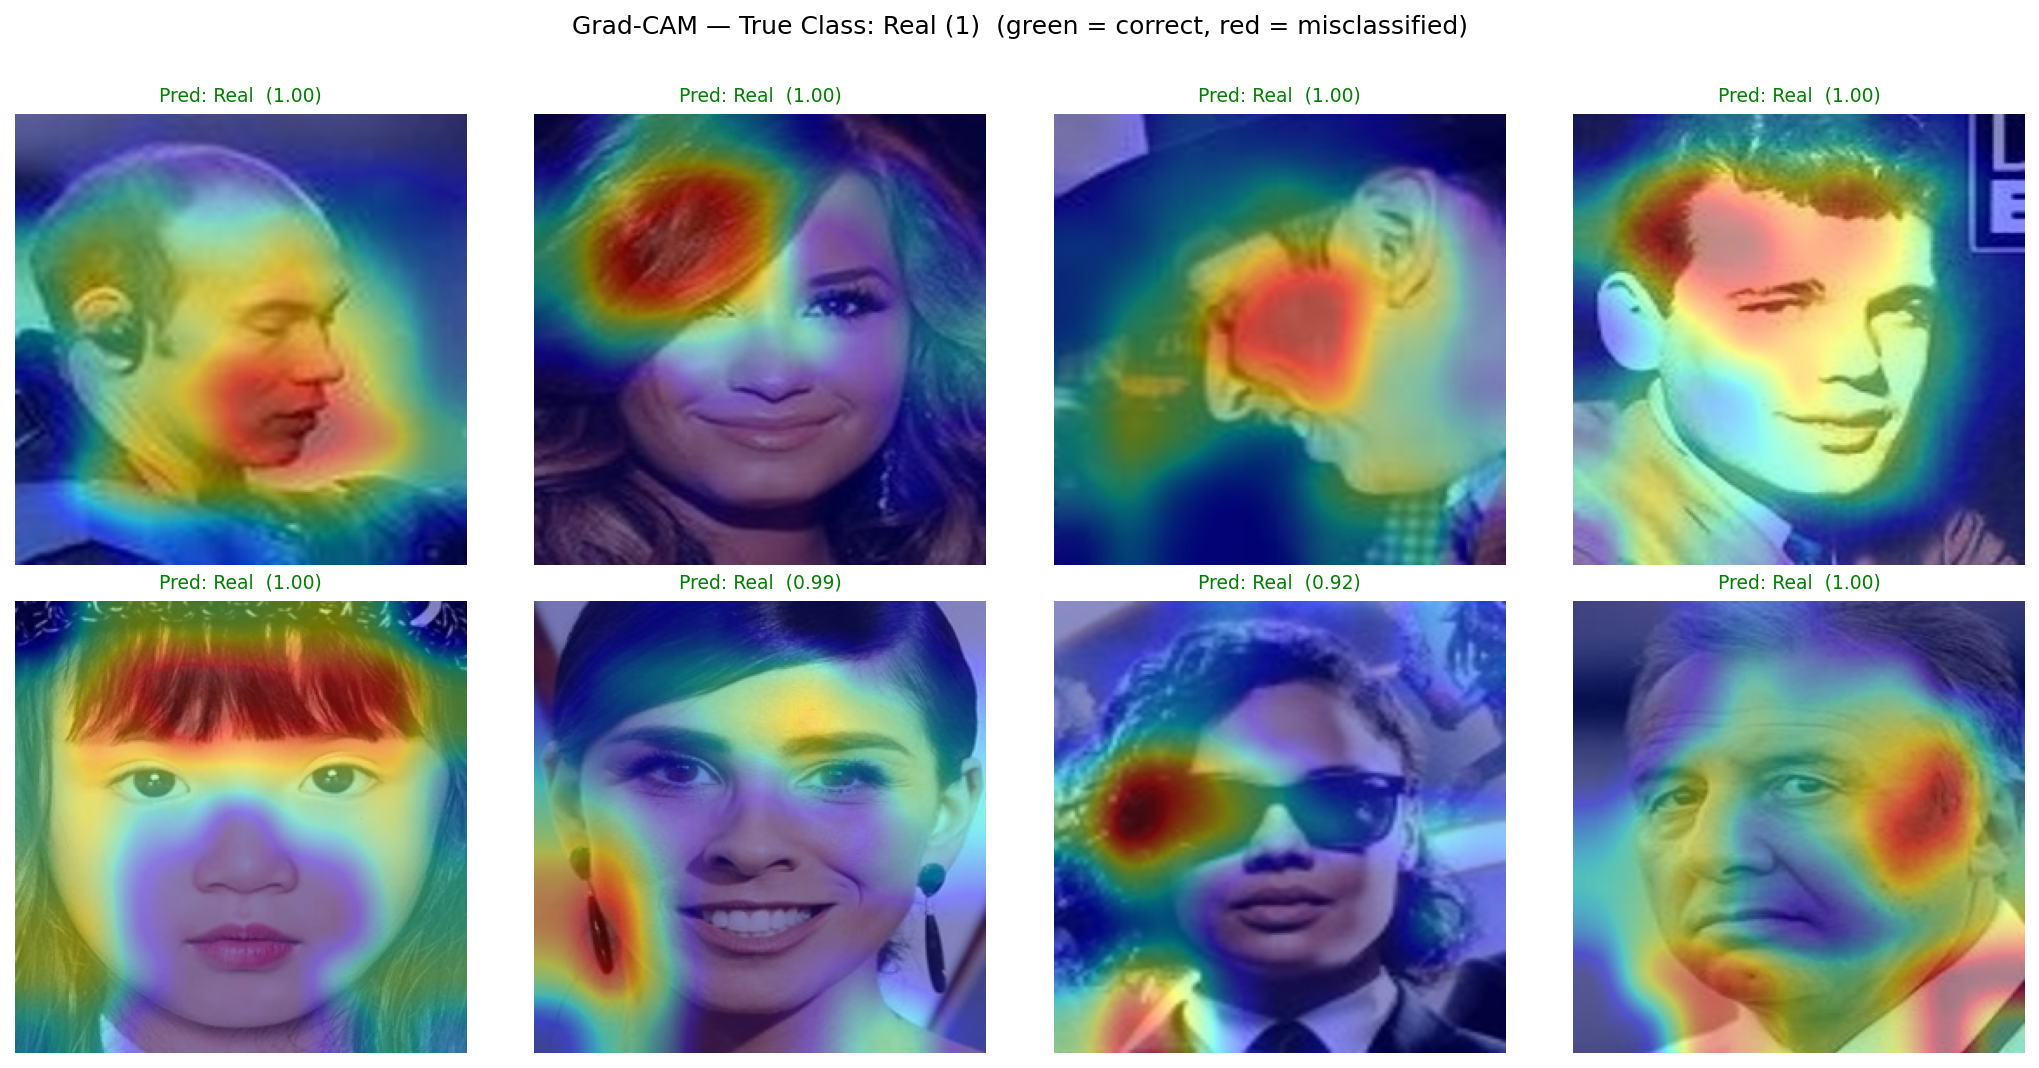

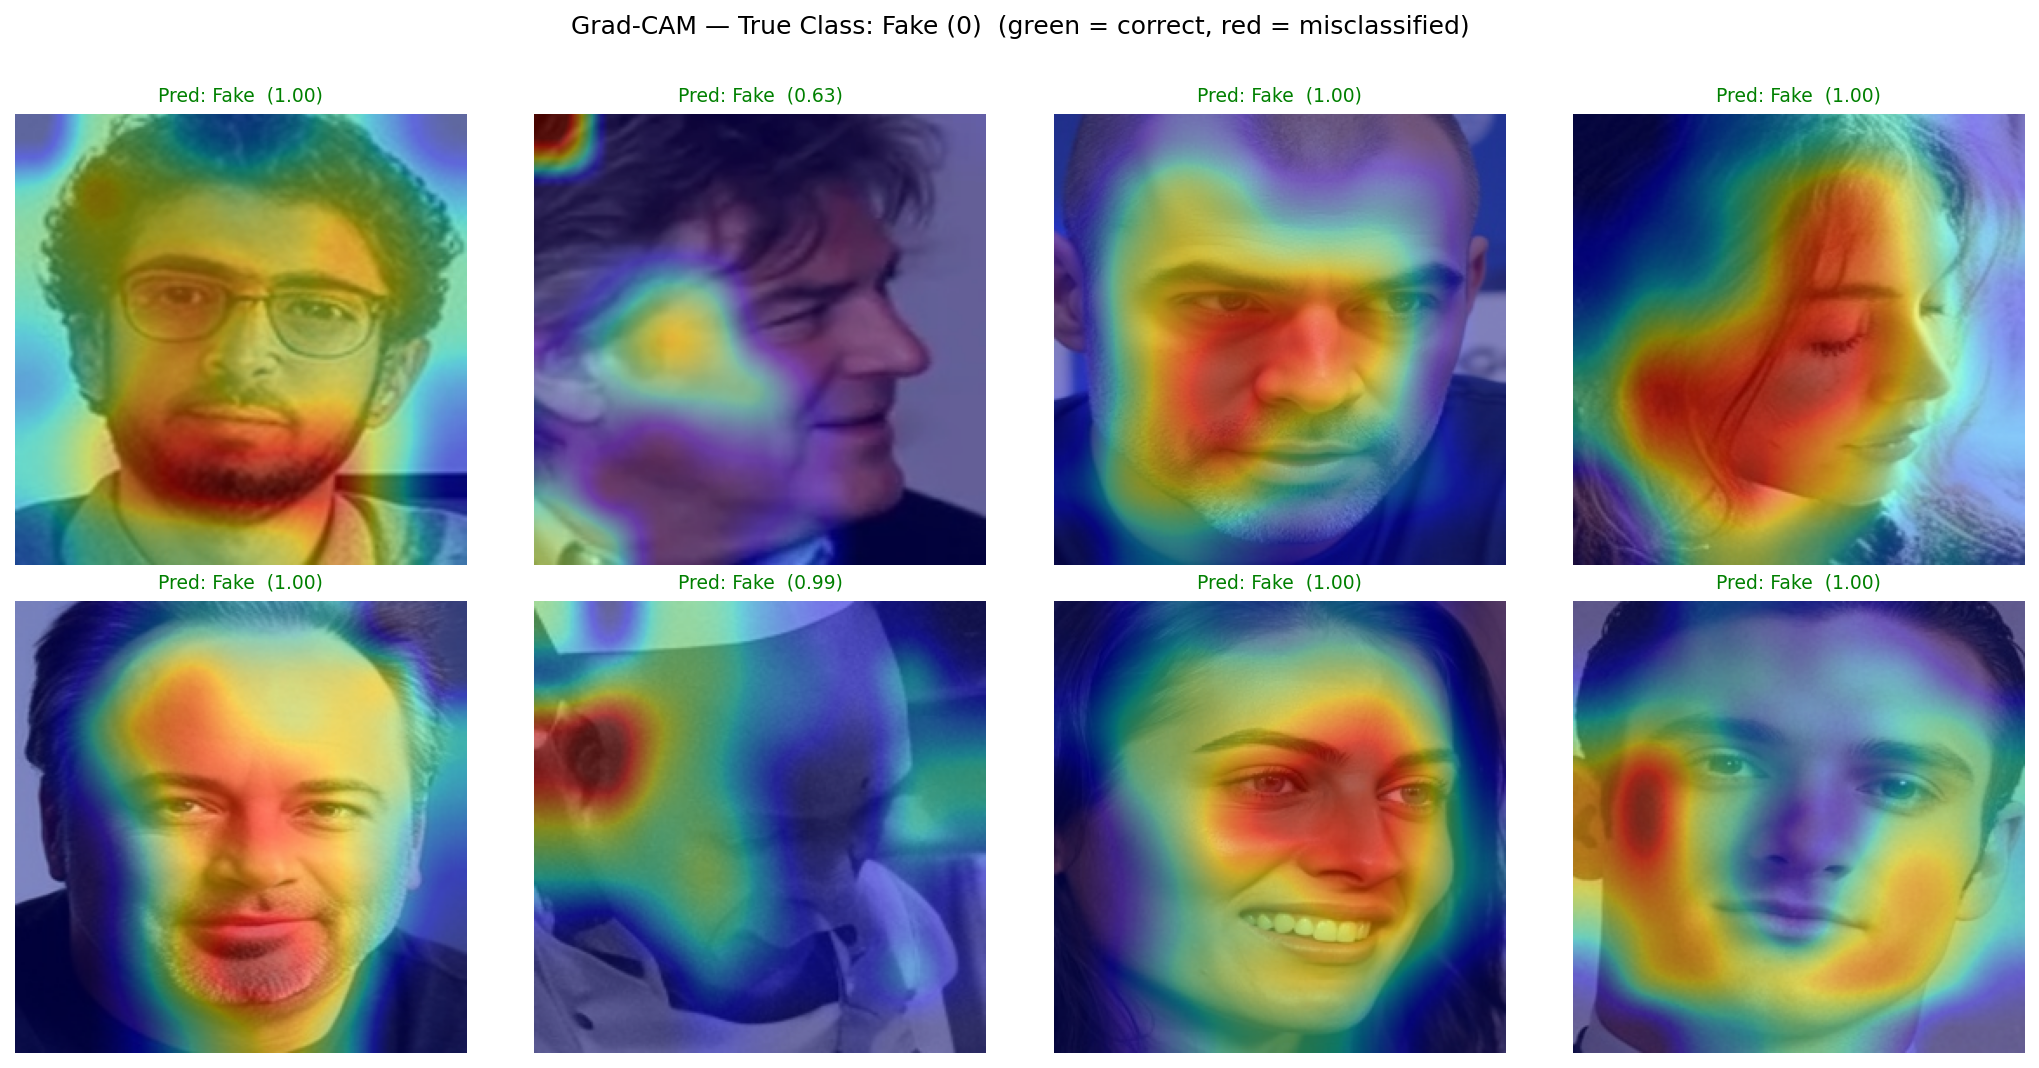

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Test Evaluation + Grad-CAM Explainability
#
# Loads best checkpoint, runs full test set evaluation, generates:
#   - Classification report (precision, recall, F1 per class)
#   - Confusion matrix
#   - ROC curve + AUC
#   - Grad-CAM heatmaps overlaid on sample predictions
#
# Grad-CAM targets the last convolutional block of EfficientNet-B2.
# Heatmaps show which spatial regions drove the real/fake prediction.
# This is your distinction-level explainability layer.
#
# Label convention (must match Cells 1-4):
#   0 = Fake
#   1 = Real
# ══════════════════════════════════════════════════════════════════════════════

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
matplotlib.use("Agg")   # non-interactive backend — safe for SageMaker
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from PIL import Image
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve,
    ConfusionMatrixDisplay,
)

# Fix 1: fallback in case SEED is not in scope from Cell 1
SEED = globals().get("SEED", 42)

# Fix 7: seed for reproducible Grad-CAM sample selection across reruns
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

CHECKPOINT_BEST  = "/home/ec2-user/SageMaker/checkpoints/best_effnetb2.pth"
RESULTS_DIR      = "/home/ec2-user/SageMaker/results"
GRADCAM_DIR      = os.path.join(RESULTS_DIR, "gradcam")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(GRADCAM_DIR, exist_ok=True)

# Number of Grad-CAM samples to generate per class (real and fake)
GRADCAM_SAMPLES_PER_CLASS = 8

# ══════════════════════════════════════════════════════════════════════════════
# LOAD BEST CHECKPOINT
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print("  CELL 5 — Test Evaluation + Grad-CAM")
print("=" * 70 + "\n")

if not os.path.exists(CHECKPOINT_BEST):
    raise FileNotFoundError(
        f"Best checkpoint not found: {CHECKPOINT_BEST}\n"
        f"Run Cell 4 first to train and save the model."
    )

print(f"Loading checkpoint: {CHECKPOINT_BEST}")
checkpoint = torch.load(CHECKPOINT_BEST, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
# Unfreeze all parameters — required for Grad-CAM backward pass to reach model.features.
# load_state_dict restores weights only, not requires_grad flags. If Cell 4 was skipped
# (running Cell 5 directly after Cell 2 on a fresh kernel), the base remains frozen from
# Cell 2 and score.backward() never reaches the target conv layer, starving the hooks.
for param in model.parameters():
    param.requires_grad = True
model.to(device)
model.eval()

print(f"  Epoch          : {checkpoint['epoch']}")
print(f"  Phase          : {checkpoint['phase']}")
print(f"  Best val loss  : {checkpoint['best_val_loss']:.4f}")
print(f"  Best val acc   : {checkpoint['best_val_acc']:.4f}")
print(f"  Best val AUC   : {checkpoint['best_val_auc']:.4f}\n")

# ══════════════════════════════════════════════════════════════════════════════
# TEST SET INFERENCE
# ══════════════════════════════════════════════════════════════════════════════

print("Running test set inference...")

# Fix 4: assert model and data are on the same device before inference begins
assert next(model.parameters()).device.type == device.type, (
    f"Model is on {next(model.parameters()).device} but device is {device}. "
    f"Move model to the correct device before running inference."
)

test_preds  = []
test_trues  = []
test_probs  = []

with torch.inference_mode():   # faster than no_grad — disables version counter, prevents accidental autograd
    for inputs, labels in test_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).long()

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(inputs)

        if outputs.ndim != 2 or outputs.size(1) != 2:
            raise ValueError(
                f"Unexpected output shape: {tuple(outputs.shape)}. "
                f"Expected [batch_size, 2]."
            )

        probs = F.softmax(outputs.float(), dim=1)[:, 1]   # P(real)
        preds = torch.argmax(outputs, dim=1)

        test_preds.extend(preds.cpu().numpy().tolist())
        test_trues.extend(labels.cpu().numpy().tolist())
        test_probs.extend(probs.cpu().numpy().tolist())

test_preds = np.array(test_preds)
test_trues = np.array(test_trues)
test_probs = np.array(test_probs)

if len(test_trues) == 0:
    raise RuntimeError(
        "Test loader produced zero samples. "
        "Check that test_loader is correctly configured and Cell 1 ran successfully."
    )

# ══════════════════════════════════════════════════════════════════════════════
# METRICS
# ══════════════════════════════════════════════════════════════════════════════

test_acc = accuracy_score(test_trues, test_preds)
test_f1  = f1_score(test_trues, test_preds, zero_division=0)
test_auc = (
    roc_auc_score(test_trues, test_probs)
    if len(np.unique(test_trues)) > 1
    else None
)

print("\n" + "=" * 70)
print("  TEST SET RESULTS")
print("=" * 70)
print(classification_report(
    test_trues, test_preds,
    target_names=["Fake (0)", "Real (1)"],
    digits=4,
    zero_division=0,
))
print(f"  Accuracy : {test_acc:.4f}")
print(f"  F1 Score : {test_f1:.4f}")
print(f"  ROC-AUC  : {test_auc:.4f}" if test_auc is not None else "  ROC-AUC  : undefined")

# ══════════════════════════════════════════════════════════════════════════════
# PLOTS — CONFUSION MATRIX + ROC CURVE
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm   = confusion_matrix(test_trues, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake (0)", "Real (1)"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Test Set Confusion Matrix", fontsize=13)

# ROC curve
if test_auc is not None:
    fpr, tpr, _ = roc_curve(test_trues, test_probs)
    axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {test_auc:.4f}")
    axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve", fontsize=13)
    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "ROC curve unavailable\n(single class in test set)",
                 ha="center", va="center", fontsize=11)
    axes[1].set_title("ROC Curve", fontsize=13)

plt.tight_layout()
metrics_plot_path = os.path.join(RESULTS_DIR, "test_metrics.png")
plt.savefig(metrics_plot_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)   # Fix 6: release figure memory — prevents accumulation on long runs
print(f"\n  Metrics plot saved -> {metrics_plot_path}")

# ══════════════════════════════════════════════════════════════════════════════
# GRAD-CAM IMPLEMENTATION
# Targets the last convolutional block of EfficientNet-B2.
# Uses hooks to capture activations and gradients — no external library needed.
# ══════════════════════════════════════════════════════════════════════════════

class GradCAM:
    """
    Gradient-weighted Class Activation Mapping for EfficientNet-B2.
    Hooks into the last convolutional block to produce spatial heatmaps
    showing which regions drove the model's prediction.
    """

    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.activations  = None
        self.gradients    = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.fwd_handle = self.target_layer.register_forward_hook(forward_hook)
        self.bwd_handle = self.target_layer.register_full_backward_hook(backward_hook)

    def remove_hooks(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    def generate(self, input_tensor, class_idx):
        """
        input_tensor : [1, 3, H, W] on device
        class_idx    : 0 (fake) or 1 (real) — the class to explain
        Returns      : numpy heatmap [H, W] in [0, 1]
        """
        assert input_tensor.size(0) == 1, (
            f"GradCAM.generate expects batch size 1, got {input_tensor.size(0)}. "
            f"Use img_tensor.unsqueeze(0) before calling generate."
        )
        # Fix B: reset stored state before each generate call — prevents stale
        # activations/gradients from a failed or partial previous pass producing
        # a heatmap from wrong tensors
        self.activations = None
        self.gradients   = None

        self.model.eval()
        self.model.zero_grad(set_to_none=True)   # Fix 3: faster than manual loop, standard practice

        output = self.model(input_tensor)
        score  = output[0, class_idx]
        score.backward(retain_graph=False)   # Fix 2: explicit — prevents silent breakage if reused

        if self.gradients is None or self.activations is None:
            raise RuntimeError(
                "Grad-CAM hooks did not capture activations or gradients. "
                "Check that target_layer is a valid intermediate layer that participates "
                "in the forward and backward pass."
            )

        # Global average pool gradients over spatial dimensions
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)   # [1, C, 1, 1]
        cam     = (weights * self.activations).sum(dim=1).squeeze()   # [H, W]
        cam     = F.relu(cam)

        # Normalise to [0, 1] — return zero map explicitly if CAM is flat
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max - cam_min > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            return np.zeros_like(cam.cpu().numpy())

        return cam.cpu().numpy()


def overlay_heatmap(img_tensor, heatmap, alpha=0.45):
    """
    Overlay a Grad-CAM heatmap on the original image.
    img_tensor : [3, H, W] normalised tensor
    heatmap    : [H, W] numpy array in [0, 1]
    Returns    : PIL Image (RGB)
    """
    # Denormalise image
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img  = (img * std + mean).clip(0, 1)

    # Resize heatmap to image size
    heatmap_pil = Image.fromarray((heatmap * 255).astype(np.uint8)).resize(
        (img.shape[1], img.shape[0]), Image.BICUBIC
    )
    heatmap_np = np.array(heatmap_pil) / 255.0

    # Apply colormap
    cmap       = plt.cm.jet
    heatmap_rgb = cmap(heatmap_np)[:, :, :3]   # drop alpha channel

    overlaid = (1 - alpha) * img + alpha * heatmap_rgb
    overlaid = (overlaid.clip(0, 1) * 255).astype(np.uint8)
    return Image.fromarray(overlaid)


# Target the last convolutional block of EfficientNet-B2
# model.features[-1] is the final MBConv block before the classifier
assert hasattr(model, "features"), (
    "model.features not found. Grad-CAM target layer cannot be set. "
    "Confirm the model architecture exposes a 'features' sequential block."
)

# Fix A: find the last actual Conv2d layer rather than hooking a container block.
# model.features[-1] is an MBConv wrapper — hooking it can yield blurry or
# inconsistent heatmaps depending on internal structure. Traversing in reverse
# guarantees we hook the true last convolutional tensor in the forward graph.
target_layer = None
for m in reversed(list(model.features.modules())):
    if isinstance(m, nn.Conv2d):
        target_layer = m
        break

if target_layer is None:
    raise ValueError(
        "No Conv2d layer found in model.features for Grad-CAM. "
        "Inspect model architecture and set target_layer manually."
    )

print(f"Grad-CAM target layer: {target_layer.__class__.__name__}  "
      f"(last Conv2d in model.features)")
gradcam = GradCAM(model, target_layer)

print("\nGenerating Grad-CAM heatmaps...")

# ── Collect sample images per class from the test loader ──────────────────────
samples_real = []   # img_tensors of true real samples for Grad-CAM
samples_fake = []   # img_tensors of true fake samples for Grad-CAM

for inputs, labels in test_loader:
    for i in range(len(inputs)):
        true_lbl = labels[i].item()
        inp      = inputs[i]

        if true_lbl == 1 and len(samples_real) < GRADCAM_SAMPLES_PER_CLASS:
            samples_real.append(inp)
        elif true_lbl == 0 and len(samples_fake) < GRADCAM_SAMPLES_PER_CLASS:
            samples_fake.append(inp)

    if (len(samples_real) >= GRADCAM_SAMPLES_PER_CLASS and
            len(samples_fake) >= GRADCAM_SAMPLES_PER_CLASS):
        break

# ── Generate and save Grad-CAM grid ───────────────────────────────────────────
def generate_gradcam_grid(samples, class_name, class_idx, filename):
    n    = len(samples)
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes      = np.array(axes).flatten()

    for ax in axes:
        ax.axis("off")

    for i, img_tensor in enumerate(samples):
        inp = img_tensor.unsqueeze(0).to(device, dtype=torch.float32)   # Fix 5: enforce FP32 — AMP is disabled for Grad-CAM

        with torch.enable_grad():
            with torch.cuda.amp.autocast(enabled=False):   # Fix 2: AMP can zero gradients in Grad-CAM — force FP32
                heatmap = gradcam.generate(inp, class_idx=class_idx)

        overlaid = overlay_heatmap(img_tensor, heatmap)

        # Get model confidence
        with torch.inference_mode():
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                logits = model(inp)
        prob     = F.softmax(logits.float(), dim=1)[0, class_idx].item()
        pred_cls = torch.argmax(logits, dim=1).item()
        pred_str = "Real" if pred_cls == 1 else "Fake"
        color    = "green" if pred_cls == class_idx else "red"

        axes[i].imshow(overlaid)
        axes[i].set_title(f"Pred: {pred_str}  ({prob:.2f})", fontsize=9, color=color)
        axes[i].axis("off")

    fig.suptitle(
        f"Grad-CAM — True Class: {class_name}  "
        f"(green = correct, red = misclassified)",
        fontsize=12, y=1.01
    )
    plt.tight_layout()
    out_path = os.path.join(GRADCAM_DIR, filename)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)   # Fix 6: release figure memory
    print(f"  Saved: {out_path}")


try:
    if len(samples_real) > 0:
        generate_gradcam_grid(samples_real, "Real (1)", class_idx=1, filename="gradcam_real_samples.png")
    else:
        print("  WARNING: No real samples collected — Grad-CAM skipped for real class.")

    if len(samples_fake) > 0:
        generate_gradcam_grid(samples_fake, "Fake (0)", class_idx=0, filename="gradcam_fake_samples.png")
    else:
        print("  WARNING: No fake samples collected — Grad-CAM skipped for fake class.")
except Exception as gradcam_exc:
    # Fix 5: Grad-CAM failure is isolated — metrics above are already computed and safe
    print(f"\n  WARNING: Grad-CAM generation failed and was skipped.\n  Reason: {gradcam_exc}")
    print("  Test metrics are unaffected. Check target layer or GPU memory.")
finally:
    gradcam.remove_hooks()   # guaranteed cleanup regardless of success or failure

# ══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print("  CELL 5 COMPLETE — Test Evaluation + Grad-CAM")
print("=" * 70)
print(f"  Test accuracy  : {test_acc:.4f}")
print(f"  Test F1        : {test_f1:.4f}")
print(f"  Test AUC       : {test_auc:.4f}" if test_auc is not None else "  Test AUC      : undefined")
print(f"  Confusion mat  : {metrics_plot_path}")
print(f"  Grad-CAM real  : {os.path.join(GRADCAM_DIR, 'gradcam_real_samples.png')}")
print(f"  Grad-CAM fake  : {os.path.join(GRADCAM_DIR, 'gradcam_fake_samples.png')}")
print("=" * 70 + "\n")

# ── Display Grad-CAM heatmaps inline ─────────────────────────────────────────
from IPython.display import Image as IPImage, display
display(IPImage(os.path.join(GRADCAM_DIR, "gradcam_real_samples.png")))
display(IPImage(os.path.join(GRADCAM_DIR, "gradcam_fake_samples.png")))

In [1]:
import boto3
import os

S3_BUCKET = "deepfake-d-100k-dataset-tw26"
S3_PREFIX = "models/Run5"

CHECKPOINTS = {
    "best_effnetb2.pth" : "/home/ec2-user/SageMaker/checkpoints/best_effnetb2.pth",
    "last_effnetb2.pth" : "/home/ec2-user/SageMaker/checkpoints/last_effnetb2.pth",
}

s3 = boto3.client("s3")

print("=" * 60)
print("  Uploading Run 5 model checkpoints to S3")
print(f"  Destination: s3://{S3_BUCKET}/{S3_PREFIX}/")
print("=" * 60)

for filename, local_path in CHECKPOINTS.items():
    if not os.path.isfile(local_path):
        print(f"\n  [SKIP] Not found: {local_path}")
        continue

    s3_key     = f"{S3_PREFIX}/{filename}"
    size_mb    = os.path.getsize(local_path) / (1024 ** 2)

    print(f"\n  Uploading {filename}  ({size_mb:.1f} MB)...")
    s3.upload_file(local_path, S3_BUCKET, s3_key)

    remote_size = s3.head_object(Bucket=S3_BUCKET, Key=s3_key)["ContentLength"]
    local_size  = os.path.getsize(local_path)

    if remote_size != local_size:
        raise RuntimeError(
            f"Verification failed for {filename}\n"
            f"  Local : {local_size:,} bytes\n"
            f"  S3    : {remote_size:,} bytes"
        )

    print(f"  Verified: s3://{S3_BUCKET}/{s3_key}  ({remote_size / (1024**2):.1f} MB)")

print(f"\n{'=' * 60}")
print("  All checkpoints uploaded and verified.")
print(f"{'=' * 60}")

  Uploading Run 5 model checkpoints to S3
  Destination: s3://deepfake-d-100k-dataset-tw26/models/Run5/

  Uploading best_effnetb2.pth  (88.9 MB)...
  Verified: s3://deepfake-d-100k-dataset-tw26/models/Run5/best_effnetb2.pth  (88.9 MB)

  Uploading last_effnetb2.pth  (88.9 MB)...
  Verified: s3://deepfake-d-100k-dataset-tw26/models/Run5/last_effnetb2.pth  (88.9 MB)

  All checkpoints uploaded and verified.
